Imports

In [22]:
import pandas as pd
import sqlite3

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns

Load sql features

In [23]:
conn = sqlite3.connect("../data/database.db")

df = pd.read_sql_query(
    "SELECT * FROM customer_features_labeled",
    conn
)

df.head()

,customer_id,age,gender,location,transaction_count,avg_transaction_amount,total_spend,avg_session_duration,avg_pages_viewed,spend_quartile,session_quartile,churn_label
0,111,55,Male,EU,3,42.103333,126.31,23.906667,13.000000,1,4,0
1,459,21,Female,US,3,47.570000,142.71,9.725000,9.500000,1,1,1
2,149,25,Male,EU,3,76.016667,228.05,17.270000,3.000000,1,3,0
3,40,52,Female,US,3,80.376667,241.13,16.900000,7.666667,1,3,0
4,384,47,Female,US,3,96.096667,288.29,17.700000,9.000000,1,3,0


Prepare Feature Table
1. Select Features

In [24]:
features = [
    "age",
    "transaction_count",
    "avg_transaction_amount",
    "total_spend",
    "avg_session_duration",
    "avg_pages_viewed"
]

X = df[features]
y = df["churn_label"]

2.Train-Test-Split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Scaale Features
1.Standardization

In [26]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Train Model
1.Logistic reg(Baseline)

In [27]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)

2. Multi-Layered Perceptron(core)

In [28]:
mlp = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    activation="relu",
    solver="adam",
    max_iter=500,
    random_state=42
)

mlp.fit(X_train_scaled, y_train)
y_pred_mlp = mlp.predict(X_test_scaled)

Evalute Model
1.Accuracy

In [29]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("MLP Accuracy:", accuracy_score(y_test, y_pred_mlp))

Logistic Regression Accuracy: 0.97
MLP Accuracy: 0.97


2.Confusion Matrix

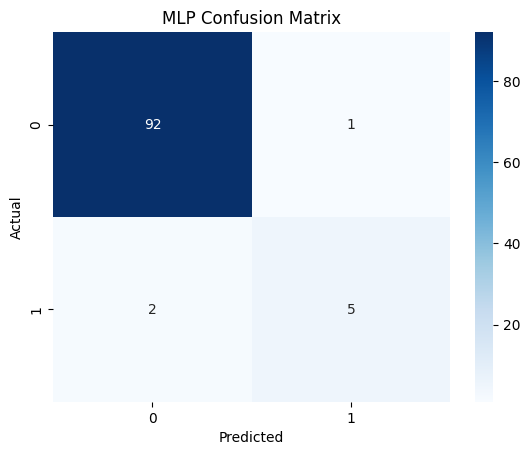

In [30]:
cm = confusion_matrix(y_test, y_pred_mlp)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("MLP Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [31]:
print("Train accuracy:", mlp.score(X_train_scaled, y_train))
print("Test accuracy:", mlp.score(X_test_scaled, y_test))

Train accuracy: 1.0
Test accuracy: 0.97
